In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from lab.sinus_vs_square_hard.data import create_data
from quantumQRC.reservoir_computing import Reservoir
from quantum_learn import build_f
from quantum_simulation.configs import quantum_parameters_config, jpc_config_dudas
from quantum_simulation.jpc_chip import JpcChip

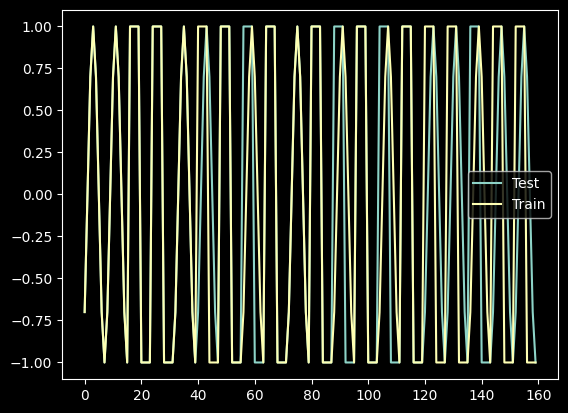

In [2]:
X_train_np, Y_train_np = create_data(20)
X_test_np, Y_test_np = create_data(20)

X_train, Y_train = jnp.array(X_train_np), jnp.array(Y_train_np)
X_test, Y_test = jnp.array(X_test_np), jnp.array(Y_test_np)

plt.plot(X_test, label='Test')
plt.plot(X_train, label='Train')
plt.legend()

In [3]:
jpc_config_dudas.summary()

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100,
    encoding_observable='g_sq',
    f_encoding=<function JPCConfig.<lambda> at 0x00000195D52C76A0>
)


In [4]:
quantum_parameters = quantum_parameters_config
chip = JpcChip(jpc_config=jpc_config_dudas)

quantum_parameters.summary()

QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)


In [5]:
QRC_probas = Reservoir(
    build_f=build_f.BuildFPhotonDistribution(jpc_config=jpc_config_dudas, clip_probas=2))

QRC_quadratures = Reservoir(build_f=build_f.BuildFQuadratures(jpc_config=jpc_config_dudas))

QRC_quadratures_poly = Reservoir(
    build_f=build_f.BuildFQuadraturesPolynomials(jpc_config=jpc_config_dudas))


In [ ]:
state_history_train = chip.run_simulation(X_train, [quantum_parameters])[0]

QRC_probas.fit(state_history=state_history_train, Y=Y_train)
QRC_quadratures.fit(state_history=state_history_train, Y=Y_train)
QRC_quadratures_poly.fit(state_history=state_history_train, Y=Y_train)

|████▊     |  47.7% ◆ elapsed 05m40s ◆ remaining 13m15s   

In [ ]:
state_history_test = chip.run_simulation(X_test, [quantum_parameters])[0]

Y_probas = QRC_probas(state_history_test)
Y_quadratures = QRC_quadratures(state_history_test)
Y_quadratures_poly = QRC_quadratures_poly(state_history_test)

In [ ]:
threshold = 0.5
Y_corr_probas = Y_probas[0] >= threshold
print(type(Y_corr_probas))
acc_probas = jnp.sum(Y_corr_probas == Y_test) / len(Y_test)
print('Accuracy probas = ', acc_probas * 1e2, '%')

Y_corr_quadratures = Y_quadratures[0] >= threshold
print(type(Y_corr_quadratures))
acc_quadratures = jnp.sum(Y_corr_quadratures == Y_test) / len(Y_test)
print('Accuracy probas = ', acc_quadratures * 1e2, '%')

Y_corr_quadratures_poly = Y_quadratures_poly[0] >= threshold
print(type(Y_corr_quadratures_poly))
acc_quadratures_poly = jnp.sum(Y_corr_quadratures_poly == Y_test) / len(Y_test)
print('Accuracy probas = ', acc_quadratures_poly * 1e2, '%')

In [ ]:
X = range(len(Y_corr_probas))
plt.scatter(X, Y_corr_probas, label='QRC probas', color='b')
plt.scatter(X, Y_corr_quadratures, label='QRC quadratures', color='g')
plt.scatter(X, Y_corr_quadratures, label='QRC quadratures poly', color='k')
plt.plot(X, Y_test, label='Target', color='r')
plt.legend()
plt.show()